# CV-QKD: The GG02 Protocol

Generated from the public notebook builder for reproducible analysis.

Notebook 04/05 leaves discrete variables behind. Instead of bits and bases (BB84), GG02 (Grosshans & Grangier, 2002) modulates the two quadratures of a coherent state and reads them out with balanced homodyne detection &mdash; the same component family used in coherent optical telecom systems.

**Convention contract.** Throughout this project we use the shot-noise-units / $\hbar = 2$ convention:
* vacuum / coherent state covariance $\gamma = I$,
* symplectic eigenvalue of vacuum $\nu = 1$,
* physical states satisfy $\nu \ge 1$.

This notebook visualises Alice's modulation, the channel's action, and the Alice-Bob mutual information. The companion notebook `05_key_rate_analysis.ipynb` runs the Holevo bound and the secure-key rate.

## 1. Bootstrap and imports

In [1]:
from pathlib import Path
import sys


def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise RuntimeError('Could not find project root')


PROJECT_ROOT = find_project_root()
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\COWLAR\projects\qkd-protocol-simulator


In [2]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

from src.cvqkd import (
    cvqkd_mutual_info_homodyne,
    cvqkd_mutual_info_heterodyne,
)
from src.channel import fiber_transmittance

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})
rng = np.random.default_rng(42)

V_A = 20.0      # Modulation variance in shot-noise units
ETA_DET = 0.6   # Homodyne detector efficiency
XI = 0.01       # Excess noise (input-referred)
N = 10_000      # Phase-space samples


## 2. Alice's two-quadrature Gaussian modulation

Alice draws $x_A$ and $p_A$ independently from $\mathcal{N}(0, V_A)$ and prepares a coherent state with displacement $\propto x_A + i\,p_A$. The cloud of $(x_A, p_A)$ samples is isotropic with radius $\sqrt{V_A}$ &mdash; that is the modulation, not the quantum noise. The shot-noise of each individual coherent state is the unit-variance vacuum spread added to every point.

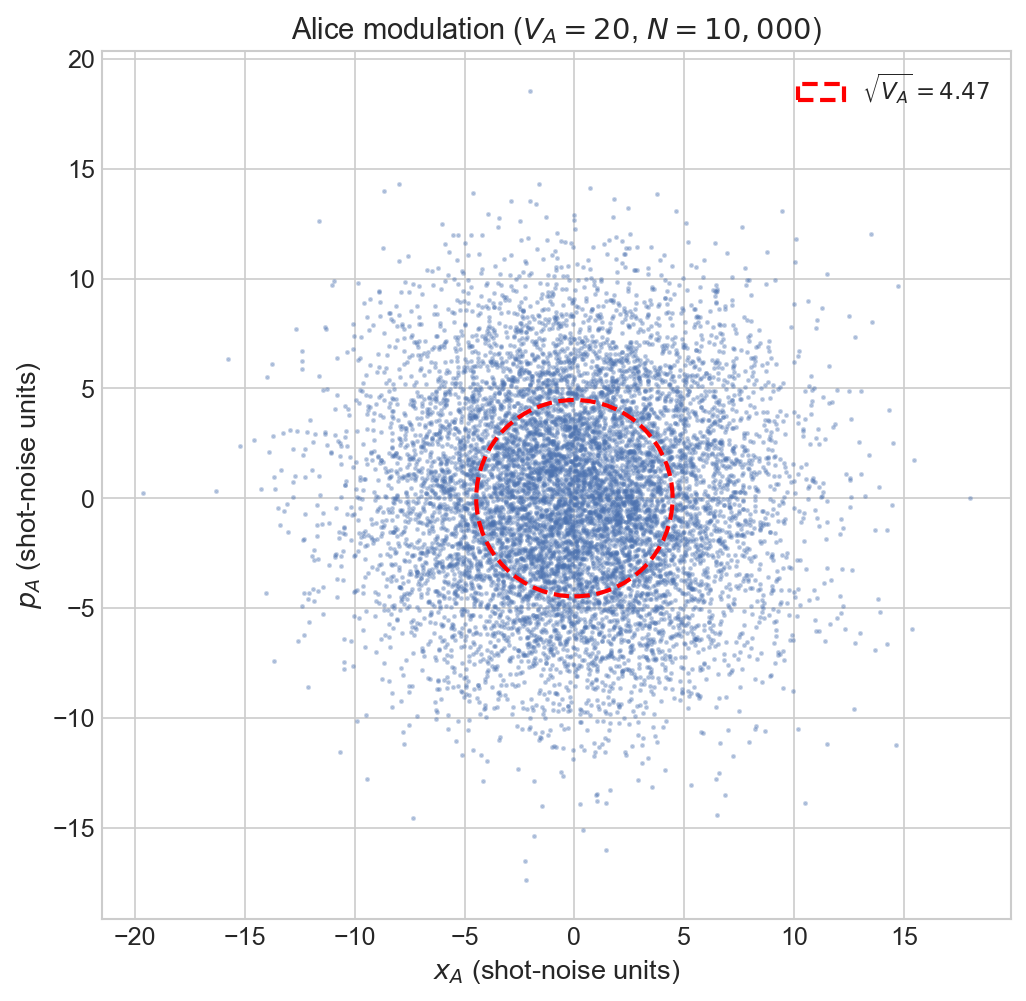

In [3]:
x_A = rng.normal(0.0, np.sqrt(V_A), N)
p_A = rng.normal(0.0, np.sqrt(V_A), N)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x_A, p_A, s=2, alpha=0.3, color='#4C72B0')
circle = plt.Circle((0.0, 0.0), np.sqrt(V_A), fill=False,
                    color='red', linestyle='--', linewidth=2,
                    label=fr'$\sqrt{{V_A}} = {np.sqrt(V_A):.2f}$')
ax.add_patch(circle)
ax.set_xlabel(r'$x_A$ (shot-noise units)', fontsize=13)
ax.set_ylabel(r'$p_A$ (shot-noise units)', fontsize=13)
ax.set_title(fr'Alice modulation ($V_A = {V_A:.0f}$, $N = {N:,}$)',
             fontsize=14)
ax.set_aspect('equal')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cvqkd_gaussian_modulation.png', dpi=300,
            bbox_inches='tight')
plt.show()


## 3. Channel action: attenuation and excess noise

Each quadrature is attenuated by $\sqrt{\eta}$ and the channel adds Gaussian noise with variance $1 + \eta\xi$ (unit shot-noise plus excess noise referred to the input). Bob's cloud is therefore *smaller* (rescaled by $\sqrt{\eta}$) and *noisier* (additional Gaussian blur). At $\eta = 0.5$ (roughly 15 km of standard fiber) and $\xi = 0.01$, both effects are visible side-by-side.

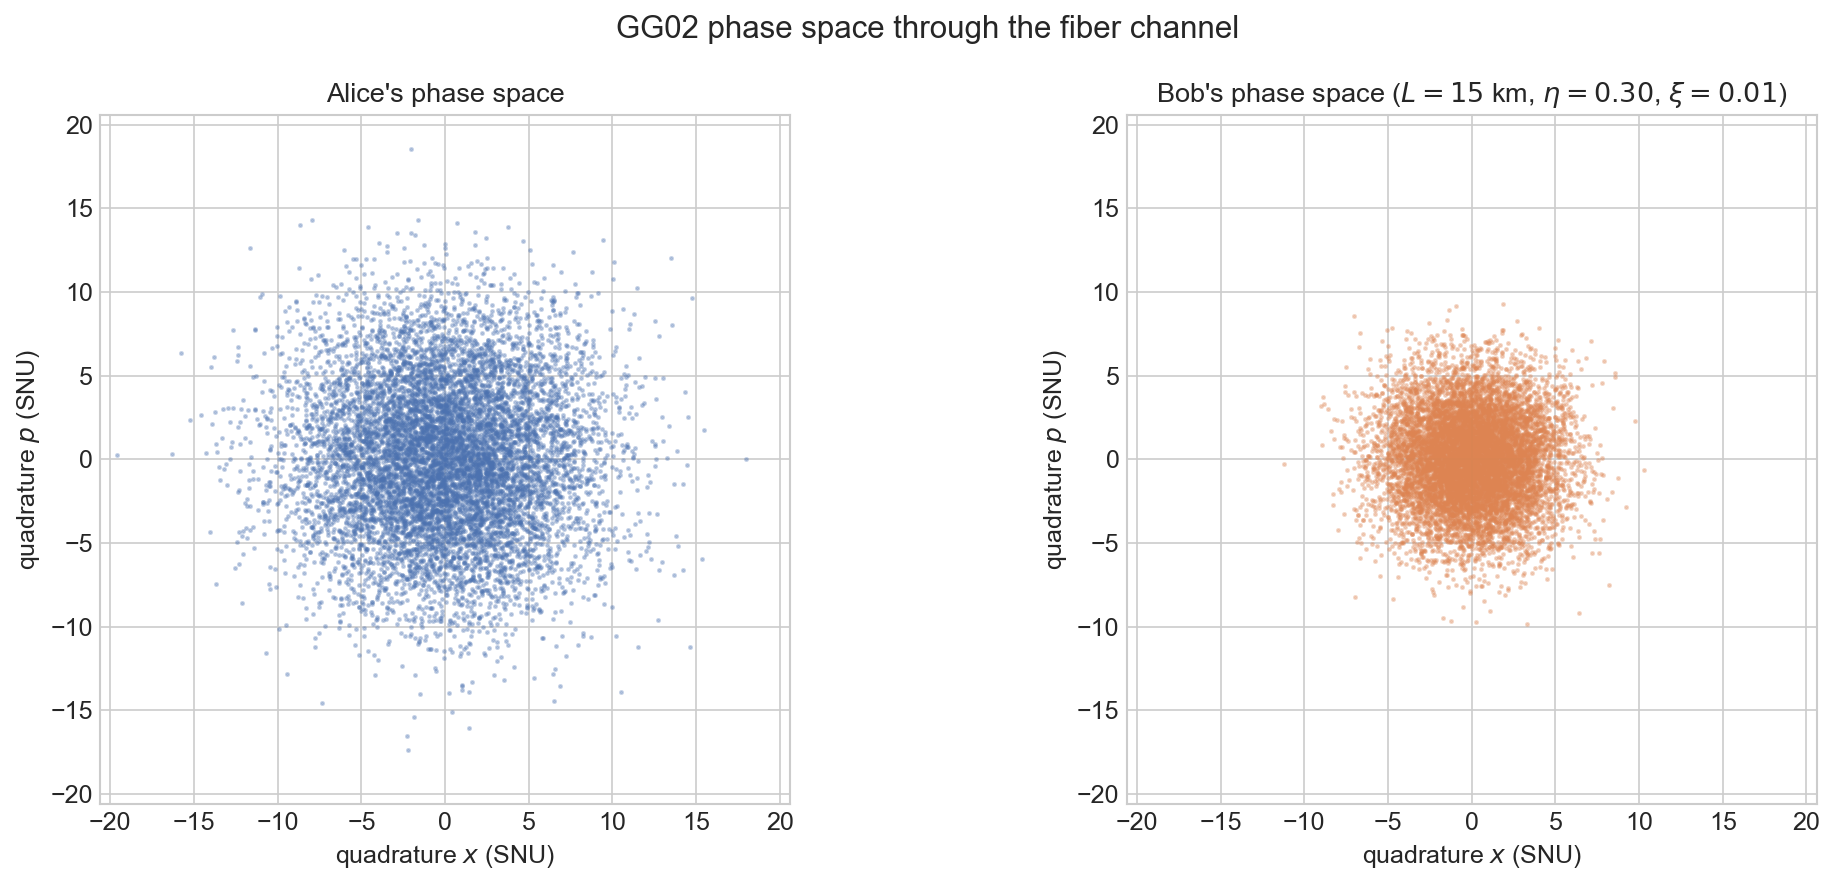

Demo: L = 15.0 km  ->  eta = 0.3007, noise variance = 1.0030


In [4]:
L_demo = 15.0  # km
eta_demo = float(fiber_transmittance(L_demo) * ETA_DET)
noise_var = 1.0 + eta_demo * XI

x_B = np.sqrt(eta_demo) * x_A + rng.normal(0.0, np.sqrt(noise_var), N)
p_B = np.sqrt(eta_demo) * p_A + rng.normal(0.0, np.sqrt(noise_var), N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(x_A, p_A, s=2, alpha=0.3, color='#4C72B0')
axes[0].set_title("Alice's phase space", fontsize=13)
axes[1].scatter(x_B, p_B, s=2, alpha=0.3, color='#DD8452')
axes[1].set_title(
    fr"Bob's phase space ($L = {L_demo:.0f}$ km, "
    fr"$\eta = {eta_demo:.2f}$, $\xi = {XI}$)",
    fontsize=13,
)
for ax in axes:
    ax.set_xlabel('quadrature $x$ (SNU)', fontsize=12)
    ax.set_ylabel('quadrature $p$ (SNU)', fontsize=12)
    ax.set_aspect('equal')
lim = float(np.max([
    np.max(np.abs(x_A)), np.max(np.abs(p_A)),
    np.max(np.abs(x_B)), np.max(np.abs(p_B)),
])) * 1.05
for ax in axes:
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
plt.suptitle('GG02 phase space through the fiber channel', fontsize=15)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cvqkd_phase_space_channel.png', dpi=300,
            bbox_inches='tight')
plt.show()

print(f'Demo: L = {L_demo} km  ->  eta = {eta_demo:.4f}, '
      f'noise variance = {noise_var:.4f}')


## 4. SNR and homodyne mutual information vs distance

$\mathrm{SNR} = \eta V_A / (1 + \eta\xi)$ on a single homodyne quadrature. The mutual information is $I(A:B) = \tfrac{1}{2} \log_2(1 + \mathrm{SNR})$. Both decay exponentially with distance because $\eta(L)$ does.

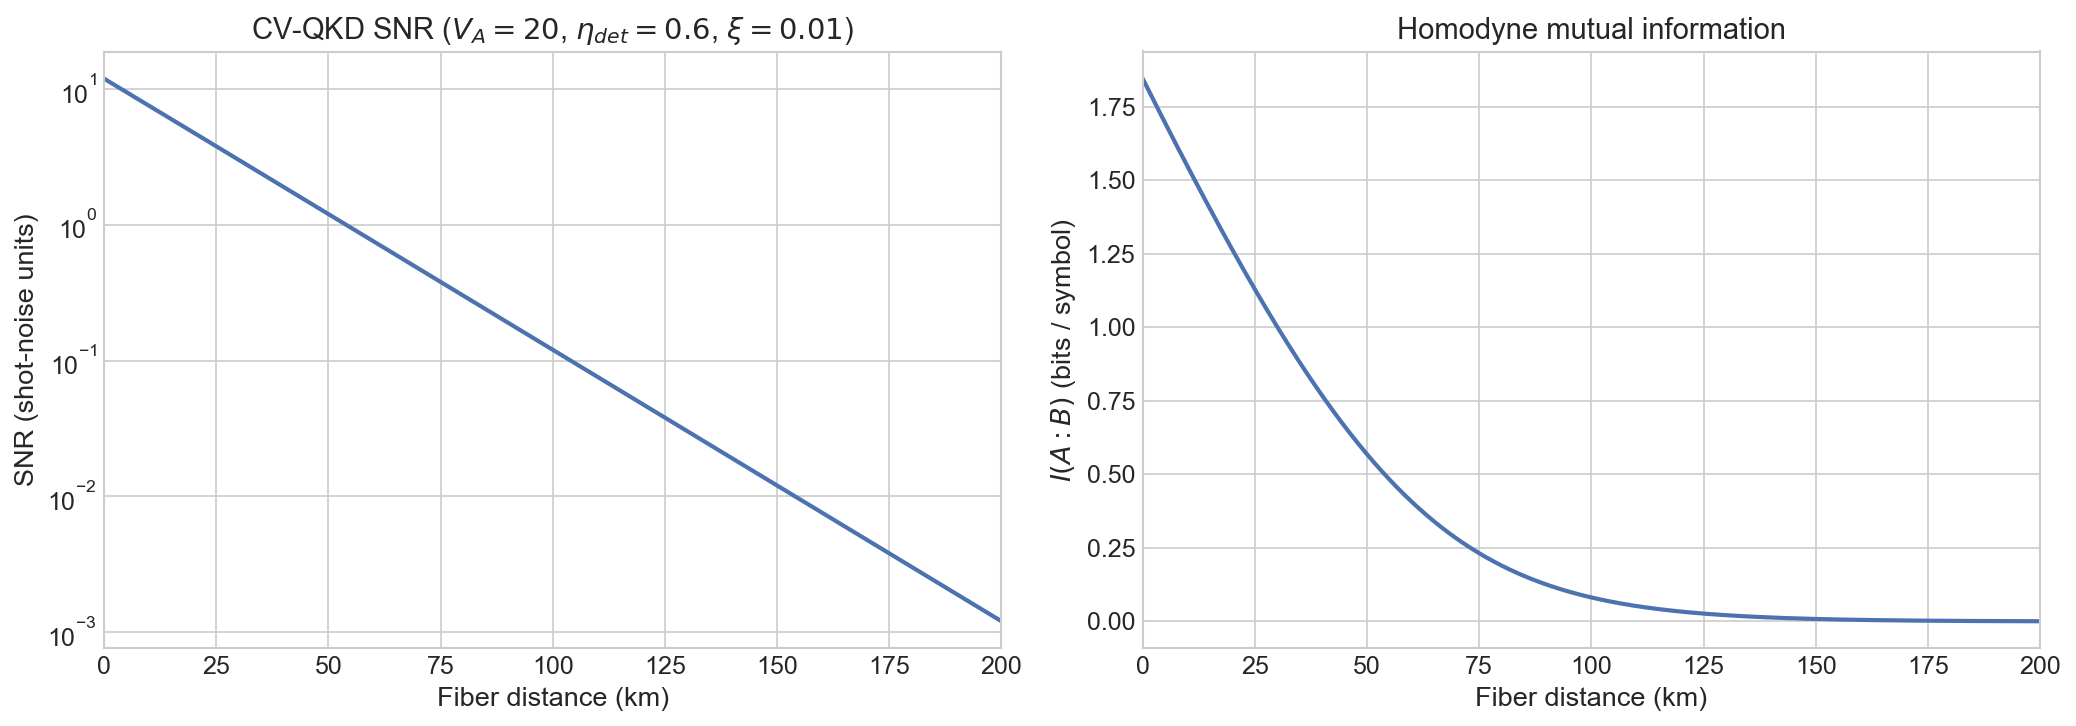

  L =   0 km  ->  eta = 6.0000e-01  I(A:B) = 1.8462 bits/symbol
  L =  25 km  ->  eta = 1.8974e-01  I(A:B) = 1.1296 bits/symbol
  L =  50 km  ->  eta = 6.0000e-02  I(A:B) = 0.5685 bits/symbol
  L =  75 km  ->  eta = 1.8974e-02  I(A:B) = 0.2320 bits/symbol
  L = 100 km  ->  eta = 6.0000e-03  I(A:B) = 0.0817 bits/symbol
  L = 150 km  ->  eta = 6.0000e-04  I(A:B) = 0.0086 bits/symbol
  L = 200 km  ->  eta = 6.0000e-05  I(A:B) = 0.0009 bits/symbol


In [5]:
L_grid = np.linspace(0.0, 200.0, 1001)
eta_grid = fiber_transmittance(L_grid) * ETA_DET
snr_grid = eta_grid * V_A / (1.0 + eta_grid * XI)
I_hom_grid = cvqkd_mutual_info_homodyne(V_A, eta_grid, XI)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].semilogy(L_grid, snr_grid, '-', color='#4C72B0', linewidth=2)
axes[0].set_xlabel('Fiber distance (km)', fontsize=13)
axes[0].set_ylabel('SNR (shot-noise units)', fontsize=13)
axes[0].set_title(
    fr'CV-QKD SNR ($V_A = {V_A:.0f}$, '
    fr'$\eta_{{det}} = {ETA_DET}$, $\xi = {XI}$)',
    fontsize=14,
)
axes[0].set_xlim(0, 200)

mask = I_hom_grid > 0
axes[1].plot(L_grid[mask], I_hom_grid[mask], '-', color='#4C72B0',
             linewidth=2)
axes[1].set_xlabel('Fiber distance (km)', fontsize=13)
axes[1].set_ylabel(r'$I(A:B)$ (bits / symbol)', fontsize=13)
axes[1].set_title('Homodyne mutual information', fontsize=14)
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.savefig(FIG_DIR / 'cvqkd_snr_and_mutual_info.png', dpi=300,
            bbox_inches='tight')
plt.show()

for L in [0, 25, 50, 75, 100, 150, 200]:
    e = float(fiber_transmittance(L) * ETA_DET)
    I = float(cvqkd_mutual_info_homodyne(V_A, e, XI))
    print(f'  L = {L:>3} km  ->  eta = {e:.4e}  I(A:B) = {I:.4f} bits/symbol')


## 5. Homodyne vs heterodyne &mdash; mutual information only

**Modeling caveat.** This panel compares the *raw* mutual information of the two detection schemes; it is **not** a secure-key comparison because we have not implemented the heterodyne Holevo bound. With one quadrature measured per channel use, homodyne carries the leading $1/2$. Heterodyne measures both quadratures but pays one extra unit of vacuum noise per arm.

$$ I_\mathrm{hom} = \tfrac{1}{2}\log_2\!\bigl(1 + \tfrac{\eta V_A}{1 + \eta\xi}\bigr), \quad I_\mathrm{het} = \log_2\!\bigl(1 + \tfrac{\eta V_A}{2 + \eta\xi}\bigr). $$